## Functions as Vectors

Functions on an interval can be treated as vectors: we have the same notions of multiplying by a constant, adding two vectors, inner product, orthogonality, and representation in an orthonormal basis. We use a **discrete grid** so we can compute and plot everything; in the continuous case the sums below become integrals.

In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 200)
dx = x[1] - x[0]

### Functions as vectors (discretization)

A function \( f \) is represented by its values \( f(x) \) on the grid. That is a vector in \( \mathbb{R}^d \) with \( d \) = number of grid points.

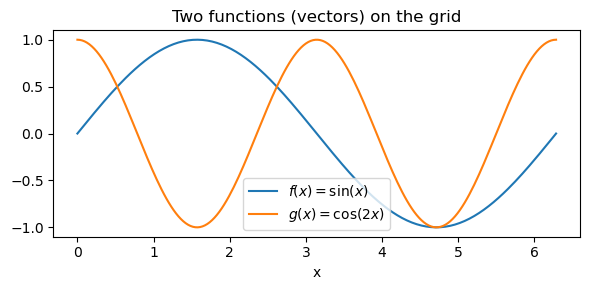

In [16]:
f = np.sin(x)
g = np.cos(2 * x)

plt.figure(figsize=(6, 3))
plt.plot(x, f, label=r"$f(x) = \sin(x)$")
plt.plot(x, g, label=r"$g(x) = \cos(2x)$")
plt.xlabel("x")
plt.legend()
plt.title("Two functions (vectors) on the grid")
plt.tight_layout()
plt.show()

### Scalar multiplication

\( (c \cdot f)(x) = c \cdot f(x) \). Same as for vectors.

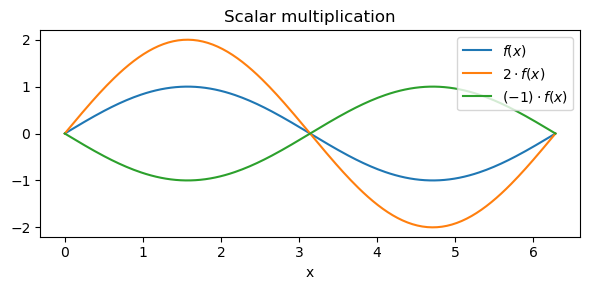

In [17]:
c1, c2 = 2, -1
plt.figure(figsize=(6, 3))
plt.plot(x, f, label=r"$f(x)$")
plt.plot(x, c1 * f, label=r"$2 \cdot f(x)$")
plt.plot(x, c2 * f, label=r"$(-1) \cdot f(x)$")
plt.xlabel("x")
plt.legend()
plt.title("Scalar multiplication")
plt.tight_layout()
plt.show()

### Addition

\( (f + g)(x) = f(x) + g(x) \).

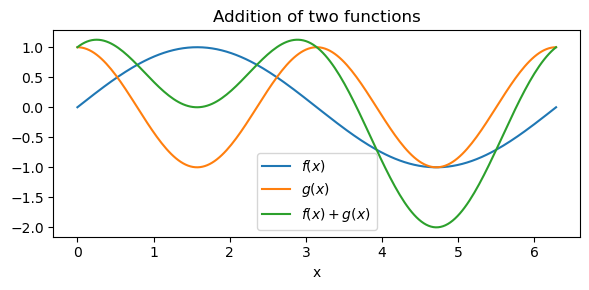

In [18]:
plt.figure(figsize=(6, 3))
plt.plot(x, f, label=r"$f(x)$")
plt.plot(x, g, label=r"$g(x)$")
plt.plot(x, f + g, label=r"$f(x) + g(x)$")
plt.xlabel("x")
plt.legend()
plt.title("Addition of two functions")
plt.tight_layout()
plt.show()

### Inner product

For the discrete version we define
$$ \langle f, g \rangle = \sum_i f(x_i) \, g(x_i) \, \Delta x $$
so it approximates \( \int f \, g \). In the continuous case the inner product would be \( \int f(x) g(x) \, dx \).

In [19]:
def inner(f, g, dx):
    return np.sum(f * g) * dx

print("<f, f> =", inner(f, f, dx))
print("<g, g> =", inner(g, g, dx))
print("<f, g> =", inner(f, g, dx))

<f, f> = 3.141592653589793
<g, g> = 3.1731664491032583
<f, g> = 0.0


### Norm

\( \|f\| = \sqrt{\langle f, f \rangle} \).

In [20]:
def norm_f(f, dx):
    return np.sqrt(inner(f, f, dx))

print("||f|| =", norm_f(f, dx))
print("||g|| =", norm_f(g, dx))

||f|| = 1.7724538509055159
||g|| = 1.7813383870290502


### Orthogonality

Two functions are **orthogonal** if \( \langle f, g \rangle = 0 \). On \( [0, 2\pi] \), \( \sin(x) \) and \( \cos(x) \) are orthogonal.

<sin(x), cos(x)> = -8.7634886884639e-19 (should be ≈ 0)


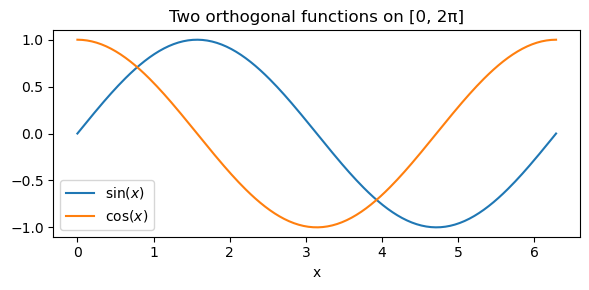

In [21]:
sin_x = np.sin(x)
cos_x = np.cos(x)
print("<sin(x), cos(x)> =", inner(sin_x, cos_x, dx), "(should be ≈ 0)")

plt.figure(figsize=(6, 3))
plt.plot(x, sin_x, label=r"$\sin(x)$")
plt.plot(x, cos_x, label=r"$\cos(x)$")
plt.xlabel("x")
plt.legend()
plt.title("Two orthogonal functions on [0, 2π]")
plt.tight_layout()
plt.show()

### Orthonormal basis

A set of functions \( \{u_1, \ldots, u_k\} \) is **orthonormal** if \( \|u_i\| = 1 \) and \( \langle u_i, u_j \rangle = 0 \) for \( i \neq j \). Then any \( f \) in their span can be written \( f = \sum_i c_i u_i \) with \( c_i = \langle f, u_i \rangle \).

On \( [0, 2\pi] \) we use: \( u_0 = 1/\sqrt{2\pi} \), \( u_1 = \cos(x)/\sqrt{\pi} \), \( u_2 = \sin(x)/\sqrt{\pi} \) (normalized so discrete norms are 1).

In [22]:
L = 2 * np.pi
u0 = np.ones_like(x) / np.sqrt(L)
u1 = np.cos(x) / np.sqrt(L / 2)
u2 = np.sin(x) / np.sqrt(L / 2)

basis = [u0, u1, u2]
for i in range(3):
    for j in range(3):
        val = inner(basis[i], basis[j], dx)
        print(f"<u{i}, u{j}> = {val:.6f}", end="  " if j < 2 else "")
    print()
print("(Should be 1 on diagonal, 0 off diagonal.")

<u0, u0> = 1.005025  <u0, u1> = 0.007107  <u0, u2> = 0.000000
<u1, u0> = 0.007107  <u1, u1> = 1.010050  <u1, u2> = -0.000000
<u2, u0> = 0.000000  <u2, u1> = -0.000000  <u2, u2> = 1.000000
(Should be 1 on diagonal, 0 off diagonal.


### Representation using the orthonormal basis

Coefficients: \( c_i = \langle f, u_i \rangle \). Reconstruction: \( f_{\text{recon}} = \sum_i c_i u_i \). If \( f \) lies in the span of \( \{u_i\} \), the reconstruction is exact; otherwise it is the best approximation in that span.

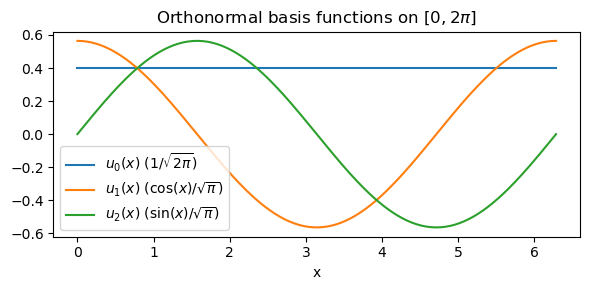

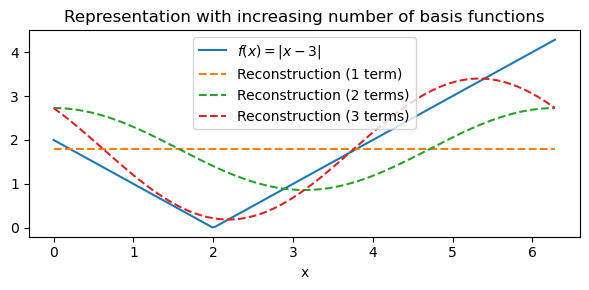

c0 = 4.496979, c1 = 1.653993, c2 = -2.314045, 


In [23]:
f_target = np.abs(x-2)

# Plot basis functions in a separate figure
plt.figure(figsize=(6, 3))
plt.plot(x, basis[0], label=r"$u_0(x)$ ($1/\sqrt{2\pi}$)")
plt.plot(x, basis[1], label=r"$u_1(x)$ ($\cos(x)/\sqrt{\pi}$)")
plt.plot(x, basis[2], label=r"$u_2(x)$ ($\sin(x)/\sqrt{\pi}$)")
plt.xlabel("x")
plt.legend()
plt.title("Orthonormal basis functions on $[0, 2\pi]$")
plt.tight_layout()
plt.show()

# Compute coefficients for all basis functions
coeffs = [inner(f_target, u, dx) for u in basis]

plt.figure(figsize=(6, 3))
plt.plot(x, f_target, label=r"$f(x) = |x-2|$")
colors = ['C1', 'C2', 'C3', 'C4']
for n_basis in range(1, len(basis) + 1):
    f_recon = sum(coeffs[i] * basis[i] for i in range(n_basis))
    label = f"Reconstruction ({n_basis} term{'s' if n_basis > 1 else ''})"
    plt.plot(x, f_recon, linestyle="--", label=label, color=colors[n_basis-1])

plt.xlabel("x")
plt.legend()
plt.title("Representation with increasing number of basis functions")
plt.tight_layout()
plt.show()

for i, c in enumerate(coeffs):
    print(f"c{i} = {c:.6f}", end=", ")
print()

### Recap

Functions on an interval can be seen as vectors. We demonstrated: **scalar multiplication**, **addition**, **inner product** (discrete sum approximating an integral), **norm**, **orthogonality**, **orthonormal basis**, and **representation** \( f = \sum_i c_i u_i \) with \( c_i = \langle f, u_i \rangle \). In the continuous case, sums are replaced by integrals.